*Note: This lab will be due after the exam, on October 14 @ midnight.*

## A/B Testing, Randomized Controlled Trials

- We want to estimate the **average treatment effect**: The average difference in outcomes between the treatment and control groups
- Remember, the stakes are something like: If we implement this intervention at the scale of millions of patients, how many lives are:
    - Saved because the treatment works and our experiment showed it did (Good)
    - Not lost because the treatment doesn't work and our experiment showed it doesn't work (Good)
    - Not saved because the treatment works but our experiment failed to show it did (Bad)
    - Lost because the treatment actually harms patients, but our experiment falsely suggested it works (Very bad)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

We generally can't compare what would have happened to observation $i$, if they had been assigned to the other treatment. This means we only observe
$$
y_{iA} = \text{Outcome for $i$ receiving treatment $A$ }
$$
or
$$
y_{iB} = \text{Outcome for $i$ receiving treatment $B$ }
$$
but not both. The **average outcome** for group $A$ is
$$
\frac{1}{\text{Size of group } A} \sum_{i \text{ receiving } A} y_{iA}
$$
and the **average outcome** for group $B$ is
$$
\frac{1}{\text{Size of group } B} \sum_{i \text{ receiving } B} y_{iB}.
$$
When we difference them, we get the **Average Treatment Effect (ATE)**:
$$
ATE = \dfrac{1}{\text{Size of group } A} \sum_{i \text{ receiving } A} y_{iA} \quad - \quad \frac{1}{\text{Size of group } B} \sum_{i \text{ receiving } B} y_{iB}
$$
As long as treatment is randomly assigned, there is no reason to think that the participants in group $A$ or $B$ are systematically different, and the **ATE** is an unbiased estimator of the true contrast in outcomes between groups $B$ and $A$. We "average away" the differences across the two groups to get an estimate of the difference in outcomes.

We then use bootstrapping to do two things:

1. Estimate the density/distribution for the averages outcomes in both groups
2. Estimate the ATE and its density/distribution

## Part 1

- First, we're going to evaluate a particular clinical trial, on chronic kidney disease:
    - ISCHEMIA-Chronic Kidney Disease Trial (ISCHEMIA-CKD)
    - ClinicalTrials.gov ID NCT01985360
    - Sponsor NYU Langone Health
    - Information provided by NYU Langone Health (Responsible Party)
- The study compared a "routine invasive therapy" (intra-aortic balloon pumps) intended to reduce death/heart attack versus more conservative medical interventions during heart surgery

<img src="./src/Intraaortic_Balloon.png" width=600>

<div>
<img src="./src/ischemia.png" width="700"/>
</div>

**1.** Load the `./data/iabp.csv` data. Cross tabulate `Group` and `Survived`. What is the point estimate of the ATE? Would you rather get the intra aortic balloon pump or not? Remember, A means pump and B means not.

In [ ]:
df = pd.read_csv('../data/iabp.csv')

## Crosstabs, average treatment effect:
print(pd.crosstab( df['Group'], df['Survived']), '\n')

ate = df.loc[ df['Group'] == 'Invasive', 'Survived'].mean() \
    - df.loc[ df['Group'] == 'Conservative', 'Survived'].mean() 
print('Estimated ATE: ', np.round(ate, 3))

Survived      0.0  1.0
Group                 
Conservative  290   99
Invasive      293   95 

Estimated ATE:  -0.01


**2.** Bootstrap the average outcome for group A, the average outcome for group B, and difference then to get the ATE, 10,000 times. Store all of these estimates. This is very important: **Bootstrap the two groups separately, since this is a clinical trial and there was random assignment (we want to maintain the balance across treatment arms).

In [3]:
## Bootstrapping:
R = 10_000

df_a = df.loc[ df['Group'] == 'Invasive',:]
df_b = df.loc[ df['Group'] == 'Conservative',:]

outcome_a = []
outcome_b = []
ate = [] # Store computed effects

for t in range(R):
    #df_t = df.sample( df.shape[0], axis=0, replace=True) # Resample

    df_at = df_a.sample(frac=1.0, replace=True)
    df_bt = df_b.sample(frac=1.0, replace=True)

    oat = df_at['Survived'].mean() # Mean outcome for A
    obt = df_bt['Survived'].mean() # Mean outcome for B    
    ate_t = oat - obt # Compute ATE for this bootstrap sample

    outcome_a.append(oat) # Save new value
    outcome_b.append(obt) # Save new value
    ate.append(ate_t) # Save new value

**3.** Make a plot of the KDEs of the outcomes for the two groups, and a plot of the ECDFs for the two groups. What relationships do you see between the two groups?

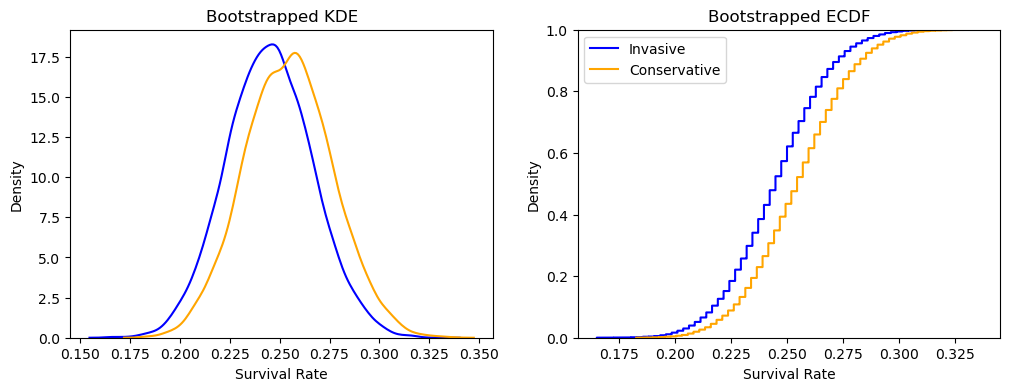

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(outcome_a, label='Invasive', color='blue', ax=ax[0])
sns.kdeplot(outcome_b, label='Conservative', color='orange', ax=ax[0]).set(title='Bootstrapped KDE', xlabel='Survival Rate', ylabel='Density')

sns.ecdfplot(outcome_a, label='Invasive', color='blue', ax=ax[1])
sns.ecdfplot(outcome_b, label='Conservative', color='orange', ax=ax[1]).set(title='Bootstrapped ECDF', xlabel='Survival Rate', ylabel='Density')

plt.legend()
plt.show()

**4.** Make a plot of the KDE and ECDF for the ATE. 

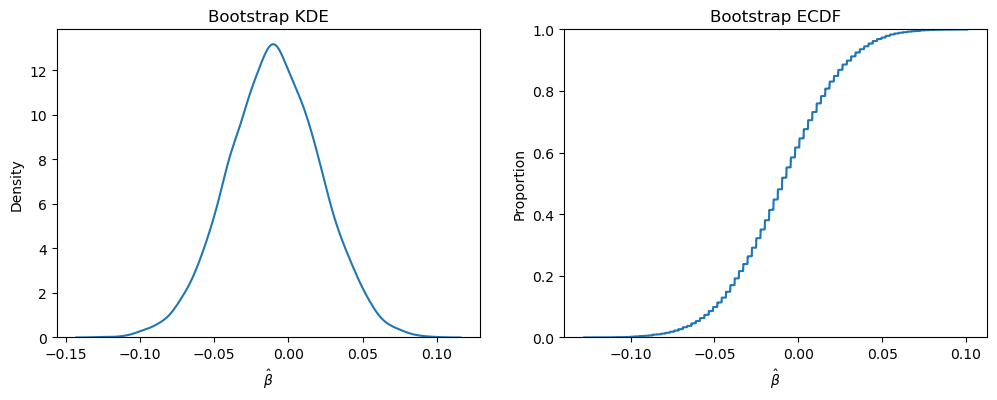

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

## KDE
sns.kdeplot(ate, ax=ax[0])
ax[0].set_xlabel(r"$\hat{\beta}$")
ax[0].set_title("Bootstrap KDE")

## ECDF
sns.ecdfplot(ate, ax=ax[1])
ax[1].set_xlabel(r"$\hat{\beta}$")
ax[1].set_title("Bootstrap ECDF")

plt.show()


**5.** Compute 90%, 95%, and 99% confidence intervals for the ATE. Is zero in those intervals? For which do we "fail to reject the null hypothesis that the effect size is zero" and for which do we "reject the null hypothesis that the effect size is zero"?

In [6]:
ci90 = np.quantile(ate, [.05, .95])
ci95 = np.quantile(ate, [.025, .975])
ci99 = np.quantile(ate, [.005, .995])

print(f"90% CI: {ci90}")
print(f"95% CI: {ci95}")
print(f"99% CI: {ci99}")

90% CI: [-0.06112024  0.04183341]
95% CI: [-0.07142289  0.05208322]
99% CI: [-0.09201498  0.07012443]


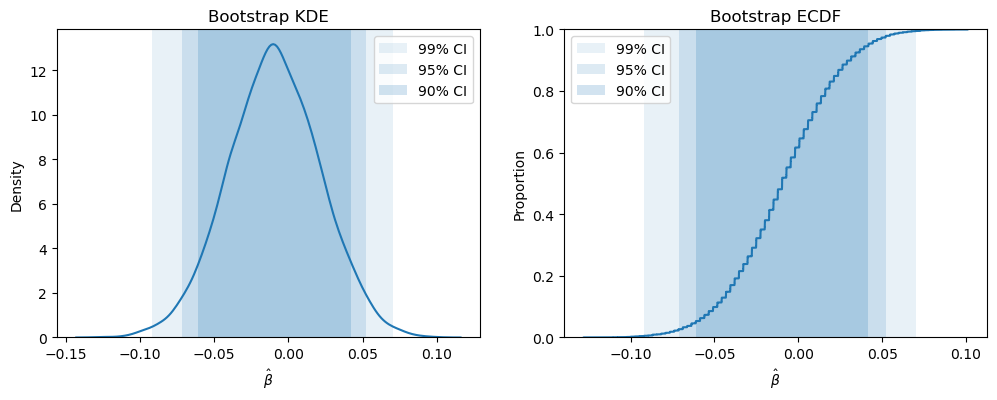

In [7]:
# Percentile bootstrap confidence intervals
ci90 = np.quantile(ate, [.05, .95])
ci95 = np.quantile(ate, [.025, .975])
ci99 = np.quantile(ate, [.005, .995])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

## KDE
sns.kdeplot(ate, ax=ax[0])

ax[0].axvspan(ci99[0], ci99[1], alpha=0.10, label="99% CI")
ax[0].axvspan(ci95[0], ci95[1], alpha=0.15, label="95% CI")
ax[0].axvspan(ci90[0], ci90[1], alpha=0.20, label="90% CI")

ax[0].set_xlabel(r"$\hat{\beta}$")
ax[0].set_title("Bootstrap KDE")
ax[0].legend()

## ECDF
sns.ecdfplot(ate, ax=ax[1])

ax[1].axvspan(ci99[0], ci99[1], alpha=0.10, label="99% CI")
ax[1].axvspan(ci95[0], ci95[1], alpha=0.15, label="95% CI")
ax[1].axvspan(ci90[0], ci90[1], alpha=0.20, label="90% CI")

ax[1].set_xlabel(r"$\hat{\beta}$")
ax[1].set_title("Bootstrap ECDF")
ax[1].legend()

**6.** What have we learned about inserting balloons into hearts?

# Part 2

In `./data/diabetes.csv`, there is data from a clinical trial considering three treatments for pre-diabetics to reduce the progression to full diabetes: metformin, rosiglitazone, and lifestyle adjustments (diet, exercise). Unlike Part 1, there aren't two treatment arms (i.e. A = aortic balloon, B = no aortic balloon), but three (met, rosi, lifestyle).

You are a data analyst working for `clinicaltrials.gov` and the FDA to provide an unbiased review of the trial's results. The researchers have provided you with `./data/diabests.csv`.

In an ipynb or py file:

1. Load the `./data/diabetes.csv` data. Cross tabulate the outcomes for the three groups. What are the average outcomes for the three groups? 
2. Bootstrap the outcomes for the three groups 10,000 times. Store all of these estimates. As this is another randomized controlled trial, do the resampling within the arms. 
3. Plot the three densities on one plot and three distributions on another. Describe any patterns you see.
4. There are three treatment effects: met versus rosi, met versus lifestyle, rosi versus lifestyle. Make KDE and ECDF plots of all these comparisons.
5. Compute confidence intervals for each pairwise ATE based on its ECDF (percentile bootstrap). Do you find any statistically significant differences between the interventions? Which seems the most effective?

Then:

6. Write a short report (3-5 paragraphs) that summarizes the evidence from the trial for adopting each of the interventions or not. Use tables and visualizations. Write in a professional tone for a technical audience, and focus on evidence (or the lack thereof). Do not assume anyone has read your work in your notebooks.